In [ ]:
import matplotlib.pyplot as plt

In [2]:
# --- OpenMP strong scaling ---
omp_threads    = [1, 2, 4, 8, 16, 32, 64, 96, 128]
omp_speedup    = [1.0000, 1.9538, 3.4530, 4.3912, 6.0963, 12.1933, 24.2204, 35.9274, 47.5279]
omp_efficiency = [1.0000, 0.9769, 0.8633, 0.5489, 0.3810, 0.3810, 0.3784, 0.3742, 0.3713]

# --- MPI strong scaling ---
mpi_s_nodes      = [1, 2, 4]
mpi_s_speedup    = [1.0000, 2.0006, 3.9933]
mpi_s_efficiency = [1.0000, 1.0003, 0.9983]

# --- MPI weak scaling ---
mpi_w_nodes      = [1, 2, 4]
mpi_w_efficiency = [1.0000, 1.0018, 0.9971]

In [3]:
def annotate_points(ax, x, y, fmt="{:.2f}", offset=(0, 8)):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt.format(yi),
            xy=(xi, yi),
            xytext=offset,
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

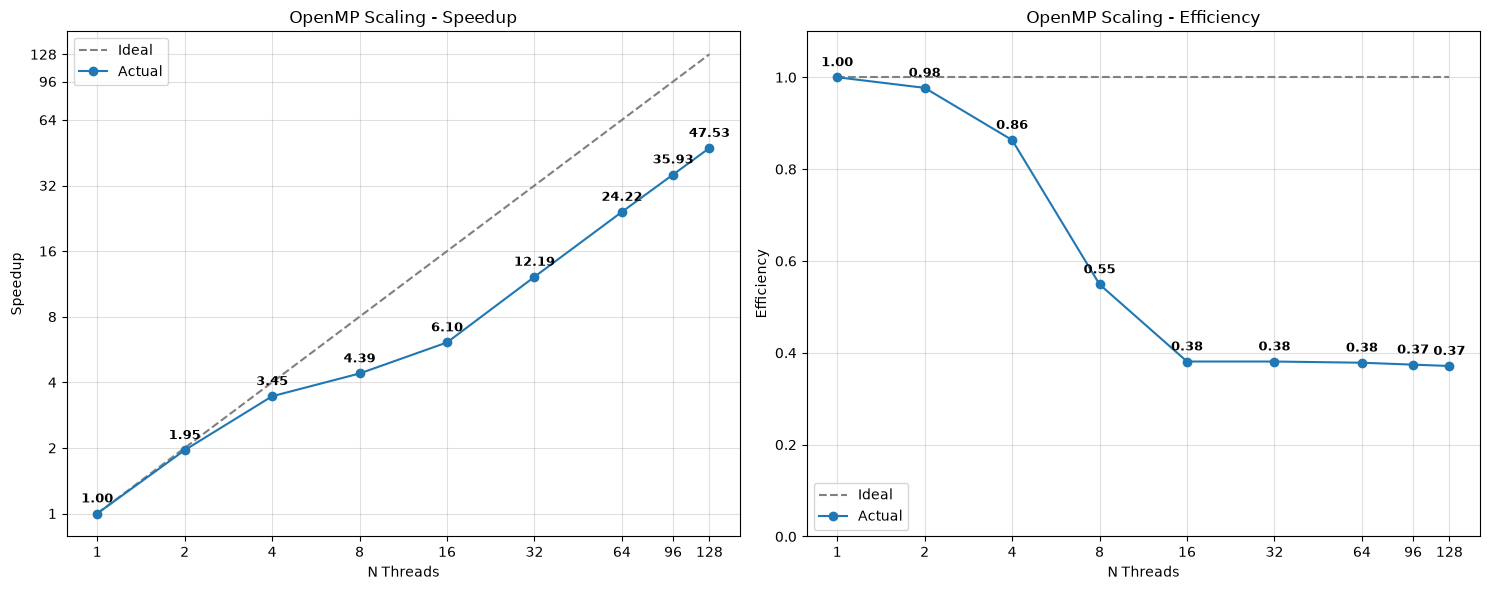

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ideal_speedup = [xi / omp_threads[0] for xi in omp_threads]
ax = axes[0]
ax.plot(omp_threads, ideal_speedup, linestyle="--", color="gray", label="Ideal")
ax.plot(omp_threads, omp_speedup, marker="o", color="tab:blue", label="Actual")
annotate_points(ax, omp_threads, omp_speedup)
ax.set_xscale("log", base=2)
ax.set_xticks(omp_threads)
ax.set_xticklabels([str(t) for t in omp_threads])
ax.minorticks_off()
ax.set_yscale("log", base=2)
ax.set_yticks(omp_threads)
ax.set_yticklabels([str(t) for t in omp_threads])
ax.minorticks_off()
ax.set_xlabel("N Threads")
ax.set_ylabel("Speedup")
ax.set_title("OpenMP Scaling - Speedup")
ax.grid(True, alpha=0.4)
ax.legend()

# # --- Efficiency panel ---
ax = axes[1]
ax.plot(omp_threads, [1.0] * len(omp_threads), linestyle="--", color="gray", label="Ideal")
ax.plot(omp_threads, omp_efficiency, marker="o", color="tab:blue", label="Actual")
annotate_points(ax, omp_threads, omp_efficiency)
ax.set_xscale("log", base=2)
ax.set_xticks(omp_threads)
ax.set_xticklabels([str(t) for t in omp_threads])
ax.minorticks_off()
ax.set_xlabel("N Threads")
ax.set_ylabel("Efficiency")
ax.set_title(f"OpenMP Scaling - Efficiency")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.4)
ax.legend()

fig.tight_layout()

In [5]:
def annotate_points(ax, x, y, fmt="{:.3f}", offset=(0, 8)):
    for xi, yi in zip(x, y):
        ax.annotate(
            fmt.format(yi),
            xy=(xi, yi),
            xytext=offset,
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

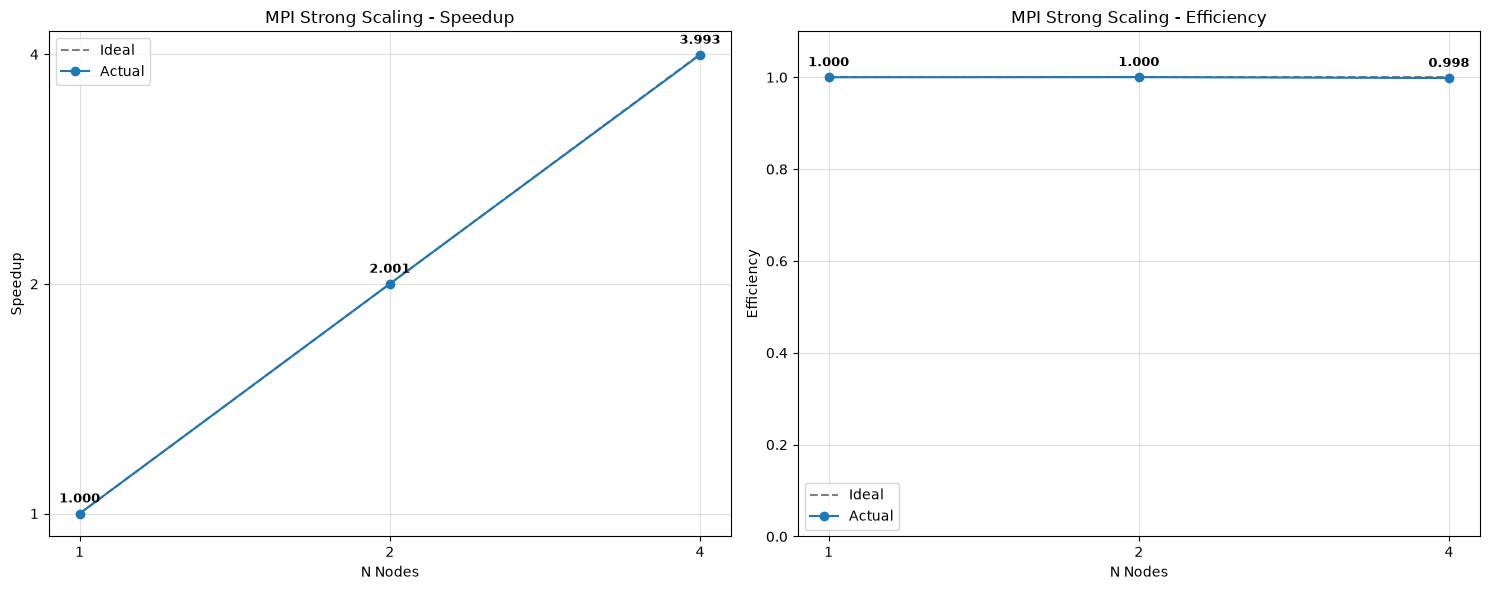

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ideal_speedup = [xi / mpi_s_nodes[0] for xi in mpi_s_nodes]
ax = axes[0]
ax.plot(mpi_s_nodes, ideal_speedup, linestyle="--", color="gray", label="Ideal")
ax.plot(mpi_s_nodes, mpi_s_speedup, marker="o", color="tab:blue", label="Actual")
annotate_points(ax, mpi_s_nodes, mpi_s_speedup)
ax.set_xscale("log", base=2)
ax.set_xticks(mpi_s_nodes)
ax.set_xticklabels([str(t) for t in mpi_s_nodes])
ax.minorticks_off()
ax.set_yscale("log", base=2)
ax.set_yticks(mpi_s_nodes)
ax.set_yticklabels([str(t) for t in mpi_s_nodes])
ax.minorticks_off()
ax.set_xlabel("N Nodes")
ax.set_ylabel("Speedup")
ax.set_title("MPI Strong Scaling - Speedup")
ax.grid(True, alpha=0.4)
ax.legend()

# # --- Efficiency panel ---
ax = axes[1]
ax.plot(mpi_s_nodes, [1.0] * len(mpi_s_nodes), linestyle="--", color="gray", label="Ideal")
ax.plot(mpi_s_nodes, mpi_s_efficiency, marker="o", color="tab:blue", label="Actual")
annotate_points(ax, mpi_s_nodes, mpi_s_efficiency)
ax.set_xscale("log", base=2)
ax.set_xticks(mpi_s_nodes)
ax.set_xticklabels([str(t) for t in mpi_s_nodes])
ax.minorticks_off()
ax.set_xlabel("N Nodes")
ax.set_ylabel("Efficiency")
ax.set_title(f"MPI Strong Scaling - Efficiency")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.4)
ax.legend()

fig.tight_layout()

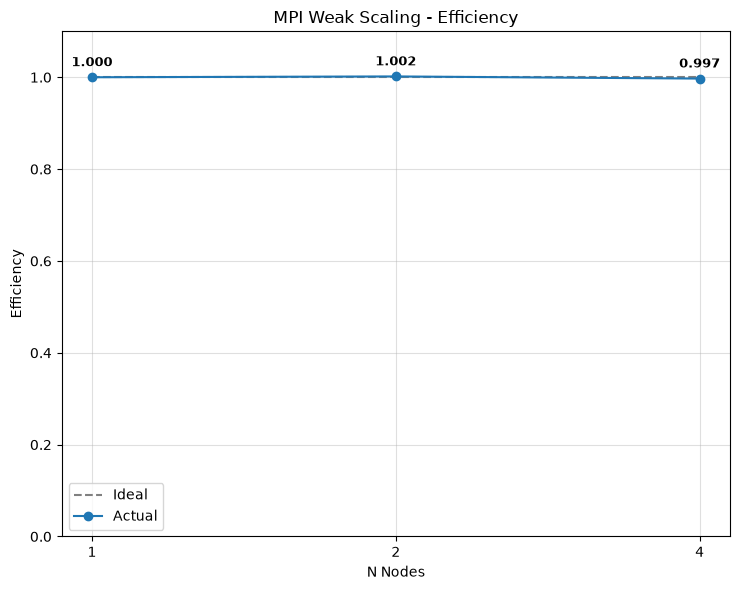

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(7.5, 6))

# # --- Efficiency panel ---
ax = axes
ax.plot(mpi_w_nodes, [1.0] * len(mpi_w_nodes), linestyle="--", color="gray", label="Ideal")
ax.plot(mpi_w_nodes, mpi_w_efficiency, marker="o", color="tab:blue", label="Actual")
annotate_points(ax, mpi_w_nodes, mpi_w_efficiency)
ax.set_xscale("log", base=2)
ax.set_xticks(mpi_w_nodes)
ax.set_xticklabels([str(t) for t in mpi_w_nodes])
ax.minorticks_off()
ax.set_xlabel("N Nodes")
ax.set_ylabel("Efficiency")
ax.set_title(f"MPI Weak Scaling - Efficiency")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.4)
ax.legend()

fig.tight_layout()